In [ ]:
!pip install rdkit

In [ ]:
!pip install rdkit-pypi
!pip install matplotlib

In [ ]:
!pip install torch

In [ ]:
!pip install torch_geometric

In [ ]:
!pip install torchvision

In [ ]:
!pip install pytorch-lightning

In [ ]:
!pip install deepchem

In [ ]:
!pip install pytorch-lightning

In [ ]:
# Import necessary libraries
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdchem
import torch
from torch_geometric.data import Data


In [ ]:
import os
import csv
import glob
import torch
import numpy as np
import networkx as nx
from torch_geometric.data import Data

In [ ]:
from typing import List, Tuple
import numpy as np

from deepchem.utils.typing import RDKitAtom, RDKitBond, RDKitMol
from deepchem.feat.graph_data import GraphData
from deepchem.feat.base_classes import MolecularFeaturizer
from deepchem.utils.molecule_feature_utils import one_hot_encode
from deepchem.utils.molecule_feature_utils import get_atom_type_one_hot
from deepchem.utils.molecule_feature_utils import construct_hydrogen_bonding_info
from deepchem.utils.molecule_feature_utils import get_atom_hydrogen_bonding_one_hot
from deepchem.utils.molecule_feature_utils import get_atom_hybridization_one_hot
from deepchem.utils.molecule_feature_utils import get_atom_total_num_Hs_one_hot
from deepchem.utils.molecule_feature_utils import get_atom_is_in_aromatic_one_hot
from deepchem.utils.molecule_feature_utils import get_atom_chirality_one_hot
from deepchem.utils.molecule_feature_utils import get_atom_formal_charge
from deepchem.utils.molecule_feature_utils import get_atom_partial_charge
from deepchem.utils.molecule_feature_utils import get_atom_total_degree_one_hot
from deepchem.utils.molecule_feature_utils import get_bond_type_one_hot
from deepchem.utils.molecule_feature_utils import get_bond_is_in_same_ring_one_hot
from deepchem.utils.molecule_feature_utils import get_bond_is_conjugated_one_hot
from deepchem.utils.molecule_feature_utils import get_bond_stereo_one_hot

In [ ]:
# from deepchem.utils.molecule_feature_utils import get_atom_formal_charge_one_hot
# from deepchem.utils.molecule_feature_utils import get_atom_implicit_valence_one_hot
# from deepchem.utils.molecule_feature_utils import get_atom_explicit_valence_one_hot
# from deepchem.utils.rdkit_utils import compute_all_pairs_shortest_path
# from deepchem.utils.rdkit_utils import compute_pairwise_ring_info

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem

In [ ]:
DEFAULT_ATOM_TYPE_SET = [
    "C",
    "N",
    "O",
    "F",
    "P",
    "S",
    "Cl",
    "Br",
    "I",
]
DEFAULT_HYBRIDIZATION_SET = ["SP", "SP2", "SP3"]
DEFAULT_TOTAL_NUM_Hs_SET = [0, 1, 2, 3, 4]
DEFAULT_FORMAL_CHARGE_SET = [-2, -1, 0, 1, 2]
DEFAULT_TOTAL_DEGREE_SET = [0, 1, 2, 3, 4, 5]
DEFAULT_RING_SIZE_SET = [3, 4, 5, 6, 7, 8]
DEFAULT_BOND_TYPE_SET = ["SINGLE", "DOUBLE", "TRIPLE", "AROMATIC"]
DEFAULT_BOND_STEREO_SET = ["STEREONONE", "STEREOANY", "STEREOZ", "STEREOE"]
DEFAULT_GRAPH_DISTANCE_SET = [1, 2, 3, 4, 5, 6, 7]
DEFAULT_ATOM_IMPLICIT_VALENCE_SET = [0, 1, 2, 3, 4, 5, 6]
DEFAULT_ATOM_EXPLICIT_VALENCE_SET = [1, 2, 3, 4, 5, 6]

USER_ATOM_TYPE_SET  = ['C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'Mg', 'Na', 'Ca',
       'Fe', 'As', 'Al', 'I', 'B', 'V', 'K', 'Tl', 'Yb', 'Sb', 'Sn', 'Ag',
       'Pd', 'Co', 'Se', 'Ti', 'Zn', 'H', 'Li', 'Ge', 'Cu', 'Au', 'Ni',
       'Cd', 'In', 'Mn', 'Zr', 'Cr', 'Pt', 'Hg', 'Pb']
USER_TOTAL_DEGREE_SET = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
USER_HYBRIDIZATION_SET = ["SP", "SP2", "SP3", 'SP3D','SP3D2']

In [ ]:
def one_hot_encode(value, allowed_values, include_unknown_set=False):
    """Create a one-hot encoded vector based on allowed values."""
    if include_unknown_set and value not in allowed_values:
        value = allowed_values[-1]

    return [1.0 if v == value else 0.0 for v in allowed_values]


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import torch
from torch_geometric.data import Data

class MolGraphConvFeaturizer:
    def __init__(self, use_edges=True, use_chirality=True, use_partial_charge=True):
        self.use_edges = use_edges
        self.use_chirality = use_chirality
        self.use_partial_charge = use_partial_charge

    def featurize(self, smiles):
        # Convert SMILES to RDKit Mol object
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        # Compute Gasteiger charges if necessary
        if self.use_partial_charge:
            try:
                AllChem.ComputeGasteigerCharges(mol)
            except:
                return None  # Unable to compute charges for this molecule

        # Get atom features
        atom_features = np.array([self._get_atom_features(atom) for atom in mol.GetAtoms()])

        # Get bond features and indices
        if self.use_edges:
            edge_indices, edge_features = self._get_bond_features(mol)
        else:
            edge_indices, edge_features = None, None

        # Create a graph data object
        graph = Data(x=torch.tensor(atom_features, dtype=torch.float),
                     edge_index=torch.tensor(edge_indices, dtype=torch.long).t().contiguous() if edge_indices is not None else None,
                     edge_attr=torch.tensor(edge_features, dtype=torch.float) if edge_features is not None else None)

        return graph

    def _get_atom_features(self, atom):
        # One-hot encoding of atom type
        atom_type = one_hot_encode(atom.GetSymbol(), USER_ATOM_TYPE_SET, include_unknown_set=True)

        # Formal charge of the atom
        formal_charge = get_atom_formal_charge(atom)

        # One-hot encoding of the atom's hybridization
        hybridization = get_atom_hybridization_one_hot(atom, USER_HYBRIDIZATION_SET, include_unknown_set=True)

        # Aromaticity of the atom
        aromatic = get_atom_is_in_aromatic_one_hot(atom)

        # One-hot encoding of the atom's degree
        degree = get_atom_total_degree_one_hot(atom, USER_TOTAL_DEGREE_SET, include_unknown_set=True)

        # One-hot encoding of the total number of hydrogens connected to the atom
        total_num_Hs = get_atom_total_num_Hs_one_hot(atom, DEFAULT_TOTAL_NUM_Hs_SET, include_unknown_set=True)

        # Concatenating all the features
        atom_feat = np.concatenate([
            atom_type, formal_charge, hybridization, aromatic, degree, total_num_Hs
        ])

        if self.use_chirality:
            chirality = get_atom_chirality_one_hot(atom)
            atom_feat = np.concatenate([atom_feat, chirality])

        if self.use_partial_charge:
            partial_charge = get_atom_partial_charge(atom)
            atom_feat = np.concatenate([atom_feat, partial_charge])

        return atom_feat

    def _get_bond_features(self, mol):
        # Initialize lists for source and destination atoms of each bond
        src, dest, bond_features = [], [], []

        for bond in mol.GetBonds():
            start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            src += [start, end]
            dest += [end, start]

            # Extract bond features and duplicate for both bond directions
            bond_feat = self._extract_bond_features(bond)
            bond_features += [bond_feat, bond_feat]

        edge_indices = [src, dest]
        #print("edge_indices : ",edge_indices)
        #print("bond_features : ",bond_features)
        return edge_indices, bond_features

    def _extract_bond_features(self, bond):
        """
        Extract bond features from a RDKit bond object.
        """

        # One-hot encoding of bond type
        bond_type = one_hot_encode(bond.GetBondTypeAsDouble(), [1.0, 1.5, 2.0, 3.0], include_unknown_set=True)

        # Whether the bond is in the same ring
        same_ring = [1.0] if bond.IsInRing() else [0.0]

        # Whether the bond is conjugated
        conjugated = [1.0] if bond.GetIsConjugated() else [0.0]

        # One-hot encoding of bond stereo configuration
        stereo = one_hot_encode(bond.GetStereo(), [Chem.rdchem.BondStereo.STEREONONE,
                                                   Chem.rdchem.BondStereo.STEREOANY,
                                                   Chem.rdchem.BondStereo.STEREOZ,
                                                   Chem.rdchem.BondStereo.STEREOE],
                                include_unknown_set=True)

        # Concatenate all bond features
        bond_feat = np.concatenate([bond_type, same_ring, conjugated, stereo])

        return bond_feat


In [ ]:
# Example usage
#featurizer = MolGraphConvFeaturizer()
#graph = featurizer.featurize('CCO')  # Example SMILES string
#print(type(graph))
#print((graph))

In [ ]:
## Assuming graphs[0] is a torch_geometric.data.Data object from your graphs list

## Print node features
#print("Len of graph:", len(graph))
#print("Node Features:")
#for i, node_feature in enumerate(graph.x):
#    print(f"Node {i}: {node_feature}")

## Print edge pairs and edge features
#print("\nEdge Pairs and Features:")
#for i, edge in enumerate(graph.edge_index.t()):
#    src, dest = edge[0].item(), edge[1].item()
#    edge_feature = graph.edge_attr[i]
#    print(f"Edge {i} - Source: {src}, Destination: {dest}, Features: {edge_feature}")


In [ ]:
#graph.is_directed()

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import torch

def visualize_graph(data):
    # Create a networkx graph
    G = nx.Graph()

    # Add nodes to the graph
    for i in range(data.num_nodes):
        G.add_node(i)

    # Add edges to the graph
    edge_index = data.edge_index.t().cpu().numpy()
    for edge in edge_index:
        src, dest = edge[0], edge[1]
        G.add_edge(src, dest)

    # Draw the graph
    pos = nx.spring_layout(G)  # positions for all nodes
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, edge_color='gray')
    plt.title("Graph Visualization")
    plt.show()
#visualize_graph(graph)

In [ ]:
# Load the data
#smiles_df = pd.read_csv("D:\\PhD\\Chapter3\\Unsupervised_GAN_Code\\pubchem-41-clean.txt", header=None, names=['SMILES'])
#smiles_df = pd.read_csv("D:\\PhD\\Chapter3\\Unsupervised_GAN_Code\\pubchem-10m-clean.txt", header=None, names=['SMILES'])
#smiles_df = pd.read_csv("D:\\PhD\\Chapter3\\Unsupervised_GAN_Code\\pubchem-10m-clean_test.txt", header=None, names=['SMILES'])
#smiles_df = pd.read_csv("D:\\PhD\\Chapter3\\Unsupervised_GAN_Code\\pubchem-10m-clean_test50k.txt", header=None, names=['SMILES'])
smiles_df = pd.read_csv("D:\\PhD\\Chapter3\\Unsupervised_GAN_Code\\pubchem-10m-clean_test25k.txt", header=None, names=['SMILES'])


In [ ]:
smiles_df.head(5)

,SMILES
0,CN(c1ccccc1)c1ccccc1C(=O)NCC1(O)CCOCC1
1,CC[NH+](CC)C1CCC([NH2+]C2CC2)(C(=O)[O-])C1
2,COCC(CNC(=O)c1ccc2c(c1)NC(=O)C2)OC
3,OCCn1cc(CNc2cccc3c2CCCC3)nn1
4,CCCCCCc1ccc(C#Cc2ccc(C#CC3=CC=C(CCC)CC3)c(C3CC...


In [ ]:
# Define a function to convert a SMILES string to a graph data object
def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Get atom features
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append(atom.GetAtomicNum())

    # Get bond features and adjacency information
    edge_indices = []
    edge_features = []
    for bond in mol.GetBonds():
        start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_indices += [(start, end), (end, start)]
        edge_feature = [bond.GetBondTypeAsDouble()]
        edge_features += [edge_feature, edge_feature]  # add twice for both directions

    # Convert to tensors
    x = torch.tensor(atom_features, dtype=torch.float).view(-1, 1)
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_features, dtype=torch.float)

    # Create a graph data object
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    return data


In [ ]:
def read_smiles_df_check(smiles_df):
    graphs = []
    invalid_indices = []
    for idx, smiles in enumerate(smiles_df['SMILES']):
        graph = smiles_to_graph(smiles)
        if graph:
            graphs.append(graph)
        else:
            print("Invalid graph :", idx,smiles)
            invalid_indices.append(idx)
    return graphs, invalid_indices

graphs, invalid_indices = read_smiles_df_check(smiles_df)
print(f"Number of valid graphs: {len(graphs)}")
print(f"Indices of invalid SMILES: {invalid_indices}")

Number of valid graphs: 25002
Indices of invalid SMILES: []


In [ ]:
# Check lengths after removal
print("Length of smiles_df:", len(smiles_df))


Length of smiles_df: 25002


In [ ]:
# Initialize the featurizer
featurizer = MolGraphConvFeaturizer(use_edges=True, use_chirality=True, use_partial_charge=True)

# Featurize SMILES strings and track invalid entries
graphs = []
invalid_indices = []
for idx, smiles in enumerate(smiles_df['SMILES']):
    print(idx)
    graph = featurizer.featurize(smiles)
    graphs.append(graph)

#    try:
#        graph = featurizer.featurize(smiles)
#        graphs.append(graph)
#    except Exception as e:
#        print(f"Invalid SMILES at index {idx}: {smiles} (Error: {e})")
#        invalid_indices.append(idx)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75


C:\Users\Malli\AppData\Local\Temp\ipykernel_2568\3029635957.py:38: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:264.)
  edge_attr=torch.tensor(edge_features, dtype=torch.float) if edge_features is not None else None)


76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
301
302
303
304
305
306
307
308
309
310
311
312
313
314
315
316
317
318
319
320
321
322
323
324
325
326
327
328
329
330
331


1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
2026
2027
2028
2029
2030
2031
2032
2033
2034
2035
2036
2037
2038
2039
2040
2041
2042
2043
2044
2045
2046
2047
2048
2049
2050
2051
2052
2053
2054
2055
2056
2057
2058
2059
2060
2061
2062
2063
2064
2065
2066
2067
2068
2069
2070
2071
2072
2073
2074
2075
2076
2077
2078
2079
2080
2081
2082
2083
2084
2085
2086
2087
2088
2089
2090
2091
2092
2093
2094
2095
2096
2097
2098
2099
2100
2101
2102
2103
2104
2105
2106
2107
2108
2109
2110
2111
2112
2113
2114
2115
2116
2117
2118
2119
2120
2121
2122
2123
2124
2125
2126
2127
2128
2129
2130
2131
2132
2133
2134
2135
2136
2137
2138
2139
2140
2141
2142
2143
2144
2145
2146
2147
2148
2149
2150
2151
2152
2153
2154
2155
2156
2157
2158
2159
2160
2161
2162
2163
2164
2165


3671
3672
3673
3674
3675
3676
3677
3678
3679
3680
3681
3682
3683
3684
3685
3686
3687
3688
3689
3690
3691
3692
3693
3694
3695
3696
3697
3698
3699
3700
3701
3702
3703
3704
3705
3706
3707
3708
3709
3710
3711
3712
3713
3714
3715
3716
3717
3718
3719
3720
3721
3722
3723
3724
3725
3726
3727
3728
3729
3730
3731
3732
3733
3734
3735
3736
3737
3738
3739
3740
3741
3742
3743
3744
3745
3746
3747
3748
3749
3750
3751
3752
3753
3754
3755
3756
3757
3758
3759
3760
3761
3762
3763
3764
3765
3766
3767
3768
3769
3770
3771
3772
3773
3774
3775
3776
3777
3778
3779
3780
3781
3782
3783
3784
3785
3786
3787
3788
3789
3790
3791
3792
3793
3794
3795
3796
3797
3798
3799
3800
3801
3802
3803
3804
3805
3806
3807
3808
3809
3810
3811
3812
3813
3814
3815
3816
3817
3818
3819
3820
3821
3822
3823
3824
3825
3826
3827
3828
3829
3830
3831
3832
3833
3834
3835
3836
3837
3838
3839
3840
3841
3842
3843
3844
3845
3846
3847
3848
3849
3850
3851
3852
3853
3854
3855
3856
3857
3858
3859
3860
3861
3862
3863
3864
3865
3866
3867
3868
3869
3870


...

18866
18867
18868
18869
18870
18871
18872
18873
18874
18875
18876
18877
18878
18879
18880
18881
18882
18883
18884
18885
18886
18887
18888
18889
18890
18891
18892
18893
18894
18895
18896
18897
18898
18899
18900
18901
18902
18903
18904
18905
18906
18907
18908
18909
18910
18911
18912
18913
18914
18915
18916
18917
18918
18919
18920
18921
18922
18923
18924
18925
18926
18927
18928
18929
18930
18931
18932
18933
18934
18935
18936
18937
18938
18939
18940
18941
18942
18943
18944
18945
18946
18947
18948
18949
18950
18951
18952
18953
18954
18955
18956
18957
18958
18959
18960
18961
18962
18963
18964
18965
18966
18967
18968
18969
18970
18971
18972
18973
18974
18975
18976
18977
18978
18979
18980
18981
18982
18983
18984
18985
18986
18987
18988
18989
18990
18991
18992
18993
18994
18995
18996
18997
18998
18999
19000
19001
19002
19003
19004
19005
19006
19007
19008
19009
19010
19011
19012
19013
19014
19015
19016
19017
19018
19019
19020
19021
19022
19023
19024
19025
19026
19027
19028
19029
19030
19031
1903

20307
20308
20309
20310
20311
20312
20313
20314
20315
20316
20317
20318
20319
20320
20321
20322
20323
20324
20325
20326
20327
20328
20329
20330
20331
20332
20333
20334
20335
20336
20337
20338
20339
20340
20341
20342
20343
20344
20345
20346
20347
20348
20349
20350
20351
20352
20353
20354
20355
20356
20357
20358
20359
20360
20361
20362
20363
20364
20365
20366
20367
20368
20369
20370
20371
20372
20373
20374
20375
20376
20377
20378
20379
20380
20381
20382
20383
20384
20385
20386
20387
20388
20389
20390
20391
20392
20393
20394
20395
20396
20397
20398
20399
20400
20401
20402
20403
20404
20405
20406
20407
20408
20409
20410
20411
20412
20413
20414
20415
20416
20417
20418
20419
20420
20421
20422
20423
20424
20425
20426
20427
20428
20429
20430
20431
20432
20433
20434
20435
20436
20437
20438
20439
20440
20441
20442
20443
20444
20445
20446
20447
20448
20449
20450
20451
20452
20453
20454
20455
20456
20457
20458
20459
20460
20461
20462
20463
20464
20465
20466
20467
20468
20469
20470
20471
20472
2047

21743
21744
21745
21746
21747
21748
21749
21750
21751
21752
21753
21754
21755
21756
21757
21758
21759
21760
21761
21762
21763
21764
21765
21766
21767
21768
21769
21770
21771
21772
21773
21774
21775
21776
21777
21778
21779
21780
21781
21782
21783
21784
21785
21786
21787
21788
21789
21790
21791
21792
21793
21794
21795
21796
21797
21798
21799
21800
21801
21802
21803
21804
21805
21806
21807
21808
21809
21810
21811
21812
21813
21814
21815
21816
21817
21818
21819
21820
21821
21822
21823
21824
21825
21826
21827
21828
21829
21830
21831
21832
21833
21834
21835
21836
21837
21838
21839
21840
21841
21842
21843
21844
21845
21846
21847
21848
21849
21850
21851
21852
21853
21854
21855
21856
21857
21858
21859
21860
21861
21862
21863
21864
21865
21866
21867
21868
21869
21870
21871
21872
21873
21874
21875
21876
21877
21878
21879
21880
21881
21882
21883
21884
21885
21886
21887
21888
21889
21890
21891
21892
21893
21894
21895
21896
21897
21898
21899
21900
21901
21902
21903
21904
21905
21906
21907
21908
2190

23203
23204
23205
23206
23207
23208
23209
23210
23211
23212
23213
23214
23215
23216
23217
23218
23219
23220
23221
23222
23223
23224
23225
23226
23227
23228
23229
23230
23231
23232
23233
23234
23235
23236
23237
23238
23239
23240
23241
23242
23243
23244
23245
23246
23247
23248
23249
23250
23251
23252
23253
23254
23255
23256
23257
23258
23259
23260
23261
23262
23263
23264
23265
23266
23267
23268
23269
23270
23271
23272
23273
23274
23275
23276
23277
23278
23279
23280
23281
23282
23283
23284
23285
23286
23287
23288
23289
23290
23291
23292
23293
23294
23295
23296
23297
23298
23299
23300
23301
23302
23303
23304
23305
23306
23307
23308
23309
23310
23311
23312
23313
23314
23315
23316
23317
23318
23319
23320
23321
23322
23323
23324
23325
23326
23327
23328
23329
23330
23331
23332
23333
23334
23335
23336
23337
23338
23339
23340
23341
23342
23343
23344
23345
23346
23347
23348
23349
23350
23351
23352
23353
23354
23355
23356
23357
23358
23359
23360
23361
23362
23363
23364
23365
23366
23367
23368
2336

24657
24658
24659
24660
24661
24662
24663
24664
24665
24666
24667
24668
24669
24670
24671
24672
24673
24674
24675
24676
24677
24678
24679
24680
24681
24682
24683
24684
24685
24686
24687
24688
24689
24690
24691
24692
24693
24694
24695
24696
24697
24698
24699
24700
24701
24702
24703
24704
24705
24706
24707
24708
24709
24710
24711
24712
24713
24714
24715
24716
24717
24718
24719
24720
24721
24722
24723
24724
24725
24726
24727
24728
24729
24730
24731
24732
24733
24734
24735
24736
24737
24738
24739
24740
24741
24742
24743
24744
24745
24746
24747
24748
24749
24750
24751
24752
24753
24754
24755
24756
24757
24758
24759
24760
24761
24762
24763
24764
24765
24766
24767
24768
24769
24770
24771
24772
24773
24774
24775
24776
24777
24778
24779
24780
24781
24782
24783
24784
24785
24786
24787
24788
24789
24790
24791
24792
24793
24794
24795
24796
24797
24798
24799
24800
24801
24802
24803
24804
24805
24806
24807
24808
24809
24810
24811
24812
24813
24814
24815
24816
24817
24818
24819
24820
24821
24822
2482

In [ ]:
# Check lengths after removal
print("Length of smiles_df:", len(smiles_df))

Length of smiles_df: 25002


In [ ]:
print(len(graphs))
print(type(graphs[1]))
print((graphs[1]))

25002
<class 'torch_geometric.data.data.Data'>
Data(x=[17, 72], edge_index=[36, 2], edge_attr=[36, 10])


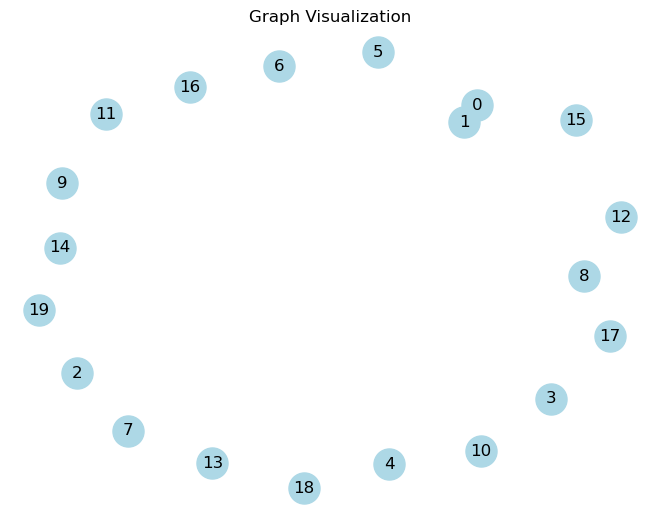

In [ ]:
visualize_graph(graphs[3])

In [ ]:
!pip install torch_geometric

In [ ]:
import networkx as nx
import torch
import numpy as np
import pandas as pd
from torch_geometric.datasets import Planetoid
from torch_geometric.utils.convert import to_networkx

In [ ]:
import torch

# Example graph object from the user's data
graph = graphs[3]

# Extracting edge indices
edge_indices = graph.edge_index.t().tolist()

# Extracting node features (assuming each node has a feature vector)
node_features = graph.x.tolist()

# The nodes can be represented as a list of indices from 0 to the number of nodes - 1
node_indices = list(range(len(node_features)))

# Displaying the node indices and edge indices
#node_indices, edge_indices
#print(node_features)

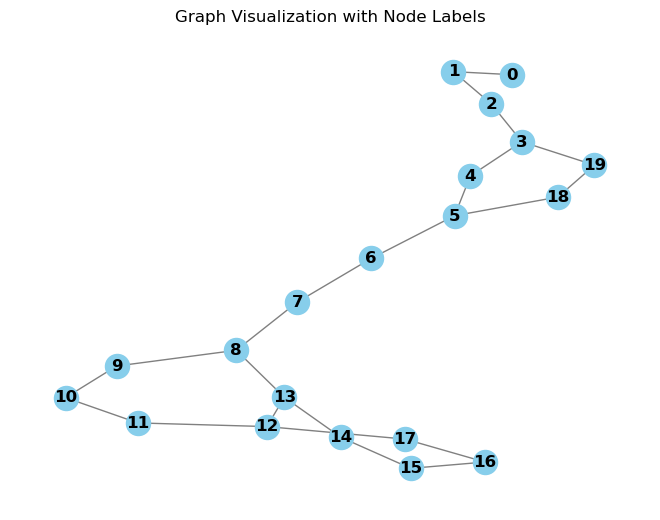

In [ ]:
import networkx as nx
import torch_geometric

edge_index = torch.tensor(edge_indices, dtype=torch.long)
x = torch.tensor(node_indices, dtype=torch.float)

data = torch_geometric.data.Data(x=x, edge_index=edge_index)
g = torch_geometric.utils.to_networkx(data, to_undirected=True)

# Draw the graph with node labels
pos = nx.spring_layout(g)  # Compute layout
nx.draw(g, pos, with_labels=True, font_weight='bold', node_color='skyblue', edge_color='gray')
plt.title("Graph Visualization with Node Labels")
plt.show()

In [ ]:
# Print the edge indices
print(graphs[3].edge_index.t().tolist())

[[0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 17, 5, 18, 18, 19, 19, 3, 13, 8, 17, 12], [1, 0, 2, 1, 3, 2, 4, 3, 5, 4, 6, 5, 7, 6, 8, 7, 9, 8, 10, 9, 11, 10, 12, 11, 13, 12, 14, 13, 15, 14, 16, 15, 17, 16, 18, 5, 19, 18, 3, 19, 8, 13, 12, 17]]


In [ ]:
# graphs[0] is a torch_geometric.data.Data object from your graphs list
graph = graphs[3]

# Print node features
print("Len of graph:", len(graph))
print("Node Features:")
print(len(graph.x))
#for i, node_feature in enumerate(graph.x):
    #print(f"Node {i}: {node_feature}")

# Print edge pairs and edge features
print("\nEdge Pairs and Features:")
print(graph.edge_index.t())
for i, edge in enumerate(graph.edge_index.t()):
    src, dest = edge[0].item(), edge[1].item()
    edge_feature = graph.edge_attr[i]
    #print(f"Edge {i} - Source: {src}, Destination: {dest}, Features: {edge_feature}")


Len of graph: 3
Node Features:
20

Edge Pairs and Features:
tensor([[ 0,  1,  1,  2,  2,  3,  3,  4,  4,  5,  5,  6,  6,  7,  7,  8,  8,  9,
          9, 10, 10, 11, 11, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 17,  5, 18,
         18, 19, 19,  3, 13,  8, 17, 12],
        [ 1,  0,  2,  1,  3,  2,  4,  3,  5,  4,  6,  5,  7,  6,  8,  7,  9,  8,
         10,  9, 11, 10, 12, 11, 13, 12, 14, 13, 15, 14, 16, 15, 17, 16, 18,  5,
         19, 18,  3, 19,  8, 13, 12, 17]])


In [ ]:
# Extracting edge list and edge features from the provided graph
graph = graphs[5]

# Extracting edge index
edge_index = graph.edge_index.t()

# Preparing the edge list
edge_list = []
for i in range(edge_index.shape[1]):
    edge = edge_index[:, i]
    edge_list.append((edge[0].item(), edge[1].item()))

edge_list


[(0, 1),
 (1, 0),
 (1, 2),
 (2, 1),
 (2, 3),
 (3, 2),
 (3, 4),
 (4, 3),
 (4, 5),
 (5, 4),
 (5, 6),
 (6, 5),
 (6, 7),
 (7, 6),
 (7, 8),
 (8, 7),
 (7, 9),
 (9, 7),
 (9, 10),
 (10, 9),
 (1, 11),
 (11, 1),
 (11, 12),
 (12, 11),
 (12, 13),
 (13, 12),
 (13, 14),
 (14, 13),
 (14, 15),
 (15, 14),
 (15, 16),
 (16, 15),
 (16, 17),
 (17, 16),
 (17, 18),
 (18, 17),
 (18, 19),
 (19, 18),
 (19, 20),
 (20, 19),
 (20, 21),
 (21, 20),
 (21, 22),
 (22, 21),
 (22, 23),
 (23, 22),
 (14, 24),
 (24, 14),
 (24, 25),
 (25, 24),
 (10, 4),
 (4, 10),
 (25, 11),
 (11, 25),
 (23, 15),
 (15, 23),
 (23, 18),
 (18, 23)]

In [ ]:
import torch
from torch_geometric.data import Data

# Assuming graph_data is your list of graph objects
# graph_data[0] is the first graph object

# Select the first graph object
first_graph = graphs[3]

# Convert node features to a floating-point type if they aren't already
node_features_float = first_graph.x.float()

# Inspect node features
print("Node features (x) of the first graph:")
print(node_features_float)
print("Shape of node features:", node_features_float.shape)

# Inspect edge features
print("\nEdge features (edge_attr) of the first graph:")
print(first_graph.edge_attr)
print("Shape of edge features:", first_graph.edge_attr.shape)

# Inspect edge index (connectivity)
print("\nEdge index (edge_index) of the first graph:")
print(first_graph.edge_index)
print("Shape of edge index:", first_graph.edge_index.shape)

# Calculate min and max for each node feature of the first graph
min_values, max_values = node_features_float.min(dim=0)[0], node_features_float.max(dim=0)[0]

print("\nMinimum values of node features:", min_values)
print("Maximum values of node features:", max_values)

# Calculate the standard deviation for each node feature
std_deviation = node_features_float.std(dim=0)
print("\nStandard deviation of node features:", std_deviation)


Node features (x) of the first graph:
tensor([[ 0.0000,  0.0000,  1.0000,  ...,  0.0000,  0.0000, -0.3944],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0628],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0658],
        ...,
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0275],
        [ 0.0000,  1.0000,  0.0000,  ...,  0.0000,  0.0000, -0.1335],
        [ 0.0000,  1.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0670]])
Shape of node features: torch.Size([20, 72])

Edge features (edge_attr) of the first graph:
tensor([[1., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 1., 1., 1., 0., 0., 0.],
        [0., 1., 0., 0., 1., 1., 1., 0., 0., 0.],
        [0., 1., 0., 0., 1., 1., 1.,

In [ ]:
smiles_df['SMILES'][3]

'OCCn1cc(CNc2cccc3c2CCCC3)nn1'

In [ ]:
mol = Chem.MolFromSmiles(smiles_df['SMILES'][3])
AllChem.ComputeGasteigerCharges(mol)

In [ ]:
edge_indices = []
for bond in mol.GetBonds():
    start_idx = bond.GetBeginAtomIdx()
    end_idx = bond.GetEndAtomIdx()
    edge_indices.append((start_idx, end_idx))
    edge_indices.append((end_idx, start_idx))  # Add the reverse direction


In [ ]:
edge_indices

[(0, 1),
 (1, 0),
 (1, 2),
 (2, 1),
 (2, 3),
 (3, 2),
 (3, 4),
 (4, 3),
 (4, 5),
 (5, 4),
 (5, 6),
 (6, 5),
 (6, 7),
 (7, 6),
 (7, 8),
 (8, 7),
 (8, 9),
 (9, 8),
 (9, 10),
 (10, 9),
 (10, 11),
 (11, 10),
 (11, 12),
 (12, 11),
 (12, 13),
 (13, 12),
 (13, 14),
 (14, 13),
 (14, 15),
 (15, 14),
 (15, 16),
 (16, 15),
 (16, 17),
 (17, 16),
 (5, 18),
 (18, 5),
 (18, 19),
 (19, 18),
 (19, 3),
 (3, 19),
 (13, 8),
 (8, 13),
 (17, 12),
 (12, 17)]

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
from torch_geometric.nn import GCNConv, global_mean_pool
from torch.nn import Linear

In [ ]:
print((graphs[0]))
print((smiles_df.head(1)))

Data(x=[25, 72], edge_index=[54, 2], edge_attr=[54, 10])
                                   SMILES
0  CN(c1ccccc1)c1ccccc1C(=O)NCC1(O)CCOCC1


In [ ]:
print(len(graphs))
print(len(smiles_df))

25002
25002


In [ ]:
# Check lengths after removal
print("Length of smiles_df:", len(smiles_df))


Length of smiles_df: 25002


In [ ]:
smiles_df.head(5)

,SMILES
0,CN(c1ccccc1)c1ccccc1C(=O)NCC1(O)CCOCC1
1,CC[NH+](CC)C1CCC([NH2+]C2CC2)(C(=O)[O-])C1
2,COCC(CNC(=O)c1ccc2c(c1)NC(=O)C2)OC
3,OCCn1cc(CNc2cccc3c2CCCC3)nn1
4,CCCCCCc1ccc(C#Cc2ccc(C#CC3=CC=C(CCC)CC3)c(C3CC...


In [ ]:
print(type(graphs[3]))

<class 'torch_geometric.data.data.Data'>


In [ ]:
# Unsupervised Graph Generative Adversarial Netwrok

In [ ]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv

In [ ]:
def generate_random_edge_index(num_nodes):
    # Example implementation to generate a random edge_index
    # Here we create a fully connected graph for simplicity
    edge_index = torch.combinations(torch.arange(num_nodes), r=2)
    return torch.cat([edge_index, edge_index.flip([1])], dim=0).t()  # Making it undirected

In [ ]:
import torch
from torch_geometric.data import Data
from torch_geometric.data import Data, Batch
from torch_geometric.utils import erdos_renyi_graph

def generate_random_noise(batch_size, node_feature_dim, edge_feature_dim, max_num_nodes):
    """
    Generate random noise for a batch of graphs with variable number of nodes and edges,
    but fixed node feature and edge feature dimensions.

    Args:
    - batch_size (int): Number of random graphs to generate.
    - node_feature_dim (int): Number of features for each node.
    - edge_feature_dim (int): Number of features for each edge.
    - max_num_nodes (int): Maximum number of nodes a graph can have.

    Returns:
    - A list of Data objects containing random noise for node and edge features.
    """
    random_graphs = []

    for _ in range(batch_size):
        # Randomly determine the number of nodes for this graph
        num_nodes = torch.randint(low=1, high=max_num_nodes, size=(1,)).item()

        # Generate random node features
        x = torch.randn(num_nodes, node_feature_dim)

        # Generate a random graph structure (edge_index)
        edge_index = erdos_renyi_graph(num_nodes, edge_prob=0.5)  # p is the probability of an edge

        # Generate random edge features (if needed)
        num_edges = edge_index.size(1)
        edge_attr = torch.randn(num_edges, edge_feature_dim) if edge_feature_dim > 0 else None

        # Create a Data object
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
        random_graphs.append(data)

    #return random_graphs
    return Batch.from_data_list(random_graphs)





In [ ]:
# Example usage
batch_size = 32
node_feature_dim = 72  # Number of node features
edge_feature_dim = 10  # Number of edge features, adjust as needed
max_num_nodes = 50    # Maximum number of nodes in a graph

random_noise_graphs = generate_random_noise(batch_size, node_feature_dim, edge_feature_dim, max_num_nodes)

In [ ]:
random_noise_graphs

DataBatch(x=[820, 72], edge_index=[2, 14116], edge_attr=[14116, 10], batch=[820], ptr=[33])

In [ ]:
# Generator Model
class Generator_v1(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Generator, self).__init__()
        self.layer1 = GCNConv(input_dim, hidden_dim)
        #print("input_dim")
        self.layer2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        #print("x, edge_index gen",type(x), type(edge_index))
        #print("x, edge_index gen",x.size(), edge_index.size())
        #print("x, edge_index gen",x, edge_index)
        x = torch.relu(self.layer1(x, edge_index))
        #print("Generator x layer 1:",x)
        x = torch.sigmoid(self.layer2(x, edge_index))
        #print("Generator x  layer 2:",x)
        return x

In [ ]:
# Generator Model
class Generator(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Generator, self).__init__()
        self.layer1 = GCNConv(input_dim, hidden_dim)
        #print("input_dim")
        self.layer2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = torch.relu(self.layer1(x, edge_index))
        x = torch.sigmoid(self.layer2(x, edge_index))

        # Generate fake edge_index (simple example, should be improved)
        fake_edge_index = self.generate_fake_edge_index(x.size(0))
        return x, fake_edge_index

    def generate_fake_edge_index(self, num_nodes):
        # Implement logic to generate a plausible edge_index for fake graphs
        # Placeholder logic: create a simple linear chain graph
        edge_index = torch.tensor([[i, i+1] for i in range(num_nodes - 1)], dtype=torch.long).t()
        return edge_index


In [ ]:
# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Discriminator, self).__init__()
        #print("In discriminator")
        self.layer1 = GCNConv(input_dim, hidden_dim)
        #print("self.layer1",input_dim,hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, 1)
        #print("self.layer2",hidden_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        #print("x, edge_index1",type(x), type(edge_index))
        #print("x, edge_index2",x.size(), edge_index.size())
        #print("x, edge_index3",x, edge_index)
        x = torch.relu(self.layer1(x, edge_index))
        #print("x 2",x)
        x = torch.sigmoid(self.layer2(x))
        #print("x 3",x)
        return x

In [ ]:
# Model Initialization
generator_input_dim = 72
generator_hidden_dim = 256
#generator_hidden_dim = 128
generator_output_dim = 72

discriminator_input_dim = 72
discriminator_hidden_dim = 256
#discriminator_hidden_dim = 128

In [ ]:
generator = Generator(generator_input_dim, generator_hidden_dim, generator_output_dim)
discriminator = Discriminator(discriminator_input_dim, discriminator_hidden_dim)

In [ ]:
import torch.optim as optim
from torch_geometric.data import DataLoader
#from torch_geometric.loader import DataLoader

from torch.utils.data import Dataset

# Sample data loader (replace with your dataset)
#data_loader = DataLoader(graphs, batch_size=32, shuffle=True)
#data_loader = DataLoader(graphs, batch_size=32, shuffle=True, follow_batch=['x', 'edge_index'])
data_loader = DataLoader(graphs, batch_size=32, shuffle=True, follow_batch=[])



# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=0.001)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.001)

# Loss function
adversarial_loss = torch.nn.BCELoss()

C:\Users\Malli\anaconda3\Lib\site-packages\torch_geometric\deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [ ]:
# Function to calculate discriminator accuracy
def calculate_discriminator_accuracy(discriminator, real_data, fake_data):
    real_predictions = discriminator(real_data).round()
    fake_predictions = discriminator(fake_data).round()
    correct_predictions = (real_predictions == 1).sum() + (fake_predictions == 0).sum()
    total_predictions = real_predictions.numel() + fake_predictions.numel()
    accuracy = 100 * correct_predictions.float() / total_predictions
    return accuracy

In [ ]:
print((data_loader))

In [ ]:
print((graphs[3].x).shape)
print((graphs[3].edge_index).shape)

torch.Size([20, 72])
torch.Size([44, 2])


In [ ]:
print((graphs[0].x).shape)
print((graphs[0].edge_index).shape)

torch.Size([25, 72])
torch.Size([54, 2])


In [ ]:
import torch
from torch_geometric.data import Data
from torch_geometric.data import Batch

def custom_graph_data_loader(graph_dataset, batch_size):
    """
    Custom data loader for graph data.

    Args:
    - graph_dataset (list of Data): The dataset containing graph Data objects.
    - batch_size (int): The size of each batch.

    Yields:
    - Batched Data object containing a batch of graphs.
    """

    def batch_graphs(graphs):
        """
        Manually batches a list of graphs into a single Batch object.
        """
        batched_edge_index = []
        batched_x = []
        batched_batch = []

        current_node_idx = 0
        for i, graph in enumerate(graphs):
            # Offset the node indices by the current_node_idx and add them to the batched edge index.
            #edge_index_offset = graph.edge_index + current_node_idx
            #batched_edge_index.append(edge_index_offset)

            # Offset only the node indices in the edge_index tensor.
            edge_index_offset = graph.edge_index.clone()  # Make a copy to avoid modifying the original graph
            edge_index_offset[0, :] += current_node_idx  # Offset source node indices
            edge_index_offset[1, :] += current_node_idx  # Offset target node indices
            #batched_edge_index.append(edge_index_offset)

            #Tring edge_index
            #batched_edge_index.append(graph.edge_index)
            batched_edge_index.append(graph.edge_index + current_node_idx)

            # Add the current graph's node features to the batched node features.
            batched_x.append(graph.x)

            # Add the graph index to the batch vector for all nodes of this graph.
            batched_batch.append(torch.full((graph.x.size(0),), i, dtype=torch.long))

            # Update the current_node_idx for the next graph.
            current_node_idx += graph.x.size(0)

        # Concatenate all the lists to create tensors.

        batched_edge_index = torch.cat(batched_edge_index, dim=0)
        batched_x = torch.cat(batched_x, dim=0)
        batched_batch = torch.cat(batched_batch, dim=0)


        # Create a new Data object to hold the batched graph.
        batched_data = Data(x=batched_x, edge_index=batched_edge_index)
        batched_data.batch = batched_batch

        return batched_data

    # Shuffle dataset at the beginning of each epoch
    indices = torch.randperm(len(graph_dataset))

    for start in range(0, len(indices), batch_size):
        end = start + batch_size
        batch_indices = indices[start:end]
        batch_graphs_list = [graph_dataset[i] for i in batch_indices]
        batch = batch_graphs(batch_graphs_list)
        yield batch


In [ ]:
import matplotlib.pyplot as plt
import torch

def calculate_accuracy(preds, labels):
    predicted_labels = preds.round()  # Convert probabilities to 0/1
    correct = (predicted_labels == labels).float()  # Convert into float for division
    accuracy = correct.sum() / len(correct)
    return accuracy

In [ ]:
# Create a NetworkX graph from node features and edge index
def create_networkx_graph(node_features, edge_index):
    G = nx.Graph()
    for i, feature in enumerate(node_features):
        G.add_node(i, feature=feature)
    for source, target in edge_index.t().numpy():
        G.add_edge(source, target)
    return G

In [ ]:
num_epochs = 20
batch_size = 32

# Lists to store metrics
epochs = []
d_losses = []
g_losses = []
real_accuracy_list =[]
fake_accuracy_list=[]
d_accuracies = []

# Initialize storage for real and fake graph
graph_data_per_epoch = {}

# To define how often to take snapshots
snapshot_interval = 5

for epoch in range(num_epochs):
    print("epoch", epoch)
    graph_data_per_epoch[epoch] = []
    for batch in custom_graph_data_loader(graphs, batch_size):
        # Generate fake data
        random_noise_graphs_batch = generate_random_noise(batch_size, node_feature_dim, edge_feature_dim, max_num_nodes)
        fake_x, fake_edge_index = generator(random_noise_graphs_batch)

        # Ensure the real edge_index is correctly shaped [2, num_edges]
        if batch.edge_index.size(0) != 2:
            batch.edge_index = batch.edge_index.t()  # Transpose if necessary

        # Create fake data batch with both x and edge_index
        fake_data = Data(x=fake_x, edge_index=fake_edge_index)

        # Labels for real and fake data (for each node)
        real_labels = torch.ones(batch.x.size(0), 1)
        fake_labels = torch.zeros(fake_data.x.size(0), 1)

        # Train Discriminator
        optimizer_D.zero_grad()
        real_loss = adversarial_loss(discriminator(batch), real_labels)
        fake_loss = adversarial_loss(discriminator(fake_data), fake_labels)
        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        # Recompute fake data and perform forward pass through discriminator
        fake_x, fake_edge_index = generator(random_noise_graphs_batch)
        fake_data = Data(x=fake_x, edge_index=fake_edge_index)
        updated_real_labels = torch.ones(fake_data.x.size(0), 1)
        g_loss = adversarial_loss(discriminator(fake_data), updated_real_labels)
        g_loss.backward()
        optimizer_G.step()

        # Calculate discriminator accuracy
        real_accuracy = calculate_accuracy(discriminator(batch).detach(), real_labels)
        print("real_accuracy",real_accuracy)
        fake_accuracy = calculate_accuracy(discriminator(fake_data).detach(), fake_labels)
        print("fake_accuracy",fake_accuracy)
        d_accuracy = (real_accuracy + fake_accuracy) / 2

        # Store metrics
        d_losses.append(d_loss.item())
        print("d_loss.item()",d_loss.item())
        g_losses.append(g_loss.item())
        print("g_loss.item()",g_loss.item())
        d_accuracies.append(d_accuracy.item())
        real_accuracy_list.append(real_accuracy.item())
        fake_accuracy_list.append(fake_accuracy.item())


        # Post-Processing for Visualization and Analysis
        #if epoch % snapshot_interval == 0:
        if epoch  == 19:
            # Store both real and fake graph data for each batch
            graph_data = {
                "real_x": batch.x.clone().detach(),
                "real_edge_index": batch.edge_index.clone().detach(),
                "fake_x": fake_x.clone().detach(),
                "fake_edge_index": fake_edge_index.clone().detach()
            }
            graph_data_per_epoch[epoch].append(graph_data)


        epochs.append(epoch)


epoch 0
real_accuracy tensor(1.)
fake_accuracy tensor(1.)
d_loss.item() 1.368009328842163
g_loss.item() 0.7595447301864624
real_accuracy tensor(1.)
fake_accuracy tensor(1.)
d_loss.item() 1.2848906517028809
g_loss.item() 0.8521713614463806
real_accuracy tensor(1.)
fake_accuracy tensor(1.)
d_loss.item() 1.208724021911621
g_loss.item() 0.9472417235374451
real_accuracy tensor(1.)
fake_accuracy tensor(1.)
d_loss.item() 1.1395071744918823
g_loss.item() 1.0423511266708374
real_accuracy tensor(1.)
fake_accuracy tensor(1.)
d_loss.item() 1.0788599252700806
g_loss.item() 1.1422808170318604
real_accuracy tensor(1.)
fake_accuracy tensor(1.)
d_loss.item() 1.02788507938385
g_loss.item() 1.237654447555542
real_accuracy tensor(1.)
fake_accuracy tensor(1.)
d_loss.item() 0.9779524207115173
g_loss.item() 1.3344948291778564
real_accuracy tensor(1.)
fake_accuracy tensor(1.)
d_loss.item() 0.9386599063873291
g_loss.item() 1.4307618141174316
real_accuracy tensor(1.)
fake_accuracy tensor(1.)
d_loss.item() 0.897

real_accuracy tensor(1.)
fake_accuracy tensor(0.9250)
d_loss.item() 0.5257248878479004
g_loss.item() 1.8039828538894653
real_accuracy tensor(1.)
fake_accuracy tensor(0.9368)
d_loss.item() 0.47945642471313477
g_loss.item() 2.0561254024505615
real_accuracy tensor(1.)
fake_accuracy tensor(0.9337)
d_loss.item() 0.590981125831604
g_loss.item() 1.6234740018844604
real_accuracy tensor(1.)
fake_accuracy tensor(0.9333)
d_loss.item() 0.5626727342605591
g_loss.item() 1.7922694683074951
real_accuracy tensor(1.)
fake_accuracy tensor(0.9223)
d_loss.item() 0.6228219270706177
g_loss.item() 1.6659786701202393
real_accuracy tensor(1.)
fake_accuracy tensor(0.9289)
d_loss.item() 0.6064357757568359
g_loss.item() 1.800180196762085
real_accuracy tensor(1.)
fake_accuracy tensor(0.9461)
d_loss.item() 0.5924110412597656
g_loss.item() 1.860306739807129
real_accuracy tensor(1.)
fake_accuracy tensor(0.9527)
d_loss.item() 0.5707553625106812
g_loss.item() 2.008789539337158
real_accuracy tensor(1.)
fake_accuracy tens

real_accuracy tensor(0.5101)
fake_accuracy tensor(1.)
d_loss.item() 1.2089037895202637
g_loss.item() 1.0505170822143555
real_accuracy tensor(0.5306)
fake_accuracy tensor(1.)
d_loss.item() 1.2012584209442139
g_loss.item() 1.054291009902954
real_accuracy tensor(0.4971)
fake_accuracy tensor(0.9989)
d_loss.item() 1.2087335586547852
g_loss.item() 1.1003016233444214
real_accuracy tensor(0.4823)
fake_accuracy tensor(1.)
d_loss.item() 1.2137415409088135
g_loss.item() 1.0985260009765625
real_accuracy tensor(0.5272)
fake_accuracy tensor(1.)
d_loss.item() 1.140523076057434
g_loss.item() 1.1149259805679321
real_accuracy tensor(0.5110)
fake_accuracy tensor(0.9973)
d_loss.item() 1.1904157400131226
g_loss.item() 1.0841532945632935
real_accuracy tensor(0.4895)
fake_accuracy tensor(1.)
d_loss.item() 1.1592649221420288
g_loss.item() 1.1766200065612793
real_accuracy tensor(0.5799)
fake_accuracy tensor(1.)
d_loss.item() 1.0805957317352295
g_loss.item() 1.1547032594680786
real_accuracy tensor(0.4956)
fake_

real_accuracy tensor(0.9870)
fake_accuracy tensor(1.)
d_loss.item() 0.442821741104126
g_loss.item() 1.484756350517273
real_accuracy tensor(0.9919)
fake_accuracy tensor(1.)
d_loss.item() 0.471203088760376
g_loss.item() 1.3800534009933472
real_accuracy tensor(1.)
fake_accuracy tensor(1.)
d_loss.item() 0.46935153007507324
g_loss.item() 1.3750637769699097
real_accuracy tensor(0.9961)
fake_accuracy tensor(1.)
d_loss.item() 0.5031013488769531
g_loss.item() 1.3013805150985718
real_accuracy tensor(0.9936)
fake_accuracy tensor(1.)
d_loss.item() 0.5205842852592468
g_loss.item() 1.3301281929016113
real_accuracy tensor(0.9892)
fake_accuracy tensor(1.)
d_loss.item() 0.5873650908470154
g_loss.item() 1.1911574602127075
real_accuracy tensor(0.9729)
fake_accuracy tensor(0.9987)
d_loss.item() 0.5991789102554321
g_loss.item() 1.2274539470672607
real_accuracy tensor(0.9793)
fake_accuracy tensor(0.9943)
d_loss.item() 0.6545203328132629
g_loss.item() 1.1042770147323608
real_accuracy tensor(0.9935)
fake_accu

real_accuracy tensor(0.8983)
fake_accuracy tensor(1.)
d_loss.item() 0.5274900197982788
g_loss.item() 1.801641821861267
real_accuracy tensor(0.9137)
fake_accuracy tensor(1.)
d_loss.item() 0.4712464213371277
g_loss.item() 1.848860263824463
real_accuracy tensor(0.9278)
fake_accuracy tensor(1.)
d_loss.item() 0.43595510721206665
g_loss.item() 1.880889654159546
real_accuracy tensor(0.9333)
fake_accuracy tensor(1.)
d_loss.item() 0.4168611168861389
g_loss.item() 1.906493067741394
real_accuracy tensor(0.9445)
fake_accuracy tensor(1.)
d_loss.item() 0.4071098864078522
g_loss.item() 1.848657488822937
real_accuracy tensor(0.9497)
fake_accuracy tensor(1.)
d_loss.item() 0.42416083812713623
g_loss.item() 1.7552249431610107
real_accuracy tensor(0.9405)
fake_accuracy tensor(1.)
d_loss.item() 0.4152935743331909
g_loss.item() 1.7636709213256836
real_accuracy tensor(0.9500)
fake_accuracy tensor(1.)
d_loss.item() 0.452755331993103
g_loss.item() 1.6035491228103638
real_accuracy tensor(0.9347)
fake_accuracy t

...

real_accuracy tensor(0.6538)
fake_accuracy tensor(0.8917)
d_loss.item() 1.1191636323928833
g_loss.item() 2.7695415019989014
real_accuracy tensor(0.7214)
fake_accuracy tensor(0.9084)
d_loss.item() 0.9427730441093445
g_loss.item() 2.794602632522583
real_accuracy tensor(0.7087)
fake_accuracy tensor(0.8867)
d_loss.item() 1.275436282157898
g_loss.item() 2.0050292015075684
real_accuracy tensor(0.6921)
fake_accuracy tensor(0.9441)
d_loss.item() 1.0501229763031006
g_loss.item() 2.0464847087860107
real_accuracy tensor(0.7274)
fake_accuracy tensor(0.9539)
d_loss.item() 0.9286700487136841
g_loss.item() 2.273538827896118
real_accuracy tensor(0.7021)
fake_accuracy tensor(0.9622)
d_loss.item() 0.9883358478546143
g_loss.item() 2.1485190391540527
real_accuracy tensor(0.7438)
fake_accuracy tensor(0.9822)
d_loss.item() 0.8466962575912476
g_loss.item() 2.0425448417663574
real_accuracy tensor(0.7933)
fake_accuracy tensor(0.9778)
d_loss.item() 1.035911202430725
g_loss.item() 2.195455551147461
real_accuracy

real_accuracy tensor(0.7948)
fake_accuracy tensor(0.9723)
d_loss.item() 0.6404430866241455
g_loss.item() 2.209482431411743
real_accuracy tensor(0.7917)
fake_accuracy tensor(0.9773)
d_loss.item() 0.6348673105239868
g_loss.item() 2.474116563796997
real_accuracy tensor(0.8732)
fake_accuracy tensor(0.9178)
d_loss.item() 1.9009387493133545
g_loss.item() 2.0539910793304443
real_accuracy tensor(0.8463)
fake_accuracy tensor(0.9157)
d_loss.item() 0.562445342540741
g_loss.item() 1.8189440965652466
real_accuracy tensor(0.8671)
fake_accuracy tensor(0.9577)
d_loss.item() 1.0765036344528198
g_loss.item() 1.5494470596313477
real_accuracy tensor(0.8859)
fake_accuracy tensor(0.8664)
d_loss.item() 0.695700466632843
g_loss.item() 1.487902045249939
real_accuracy tensor(0.8773)
fake_accuracy tensor(0.9634)
d_loss.item() 0.863307774066925
g_loss.item() 1.7250884771347046
real_accuracy tensor(0.7879)
fake_accuracy tensor(0.9466)
d_loss.item() 0.6837923526763916
g_loss.item() 2.1045329570770264
real_accuracy 

real_accuracy tensor(0.8432)
fake_accuracy tensor(1.)
d_loss.item() 0.45051348209381104
g_loss.item() 2.286818742752075
real_accuracy tensor(0.8132)
fake_accuracy tensor(0.9955)
d_loss.item() 0.4927017390727997
g_loss.item() 2.266984701156616
real_accuracy tensor(0.8275)
fake_accuracy tensor(0.9960)
d_loss.item() 0.49516409635543823
g_loss.item() 2.2105777263641357
real_accuracy tensor(0.8368)
fake_accuracy tensor(0.9408)
d_loss.item() 0.7937910556793213
g_loss.item() 1.7727099657058716
real_accuracy tensor(0.8481)
fake_accuracy tensor(0.9796)
d_loss.item() 1.775365948677063
g_loss.item() 1.8832297325134277
real_accuracy tensor(0.8622)
fake_accuracy tensor(0.9866)
d_loss.item() 1.3452751636505127
g_loss.item() 1.8352049589157104
real_accuracy tensor(0.8493)
fake_accuracy tensor(0.9653)
d_loss.item() 0.6972104907035828
g_loss.item() 1.8034369945526123
real_accuracy tensor(0.8842)
fake_accuracy tensor(0.9837)
d_loss.item() 0.831856369972229
g_loss.item() 1.7834663391113281
real_accuracy 

real_accuracy tensor(0.8525)
fake_accuracy tensor(0.9975)
d_loss.item() 0.4703601002693176
g_loss.item() 1.7951849699020386
real_accuracy tensor(0.8237)
fake_accuracy tensor(1.)
d_loss.item() 0.5148075222969055
g_loss.item() 1.7448381185531616
real_accuracy tensor(0.8736)
fake_accuracy tensor(0.9863)
d_loss.item() 0.81247878074646
g_loss.item() 2.0142509937286377
real_accuracy tensor(0.8431)
fake_accuracy tensor(0.9987)
d_loss.item() 0.40768539905548096
g_loss.item() 2.347433567047119
real_accuracy tensor(0.8301)
fake_accuracy tensor(0.9538)
d_loss.item() 0.5823807716369629
g_loss.item() 2.1419734954833984
real_accuracy tensor(0.7915)
fake_accuracy tensor(0.9973)
d_loss.item() 0.5454020500183105
g_loss.item() 2.117666006088257
real_accuracy tensor(0.8699)
fake_accuracy tensor(0.9927)
d_loss.item() 0.4498169422149658
g_loss.item() 1.9219664335250854
real_accuracy tensor(0.8696)
fake_accuracy tensor(1.)
d_loss.item() 0.430987685918808
g_loss.item() 1.8501451015472412
real_accuracy tensor

real_accuracy tensor(0.8542)
fake_accuracy tensor(0.9770)
d_loss.item() 0.6544620990753174
g_loss.item() 1.8643560409545898
real_accuracy tensor(0.8319)
fake_accuracy tensor(0.9097)
d_loss.item() 1.699937105178833
g_loss.item() 1.7950503826141357
real_accuracy tensor(0.8106)
fake_accuracy tensor(0.9786)
d_loss.item() 0.8740854263305664
g_loss.item() 2.011807441711426
real_accuracy tensor(0.8199)
fake_accuracy tensor(0.9950)
d_loss.item() 0.752048909664154
g_loss.item() 2.072883129119873
real_accuracy tensor(0.8002)
fake_accuracy tensor(0.9550)
d_loss.item() 0.5713138580322266
g_loss.item() 2.024972677230835
real_accuracy tensor(0.7971)
fake_accuracy tensor(0.9859)
d_loss.item() 0.5732316970825195
g_loss.item() 2.002671957015991
real_accuracy tensor(0.8225)
fake_accuracy tensor(0.9488)
d_loss.item() 0.5896587371826172
g_loss.item() 1.8247101306915283
real_accuracy tensor(0.8172)
fake_accuracy tensor(0.9507)
d_loss.item() 0.9577021598815918
g_loss.item() 1.7582197189331055
real_accuracy 

In [ ]:
# Plotting
plt.figure(figsize=(12, 4))

# Plot Discriminator Loss
plt.subplot(1, 3, 1)
plt.plot(d_losses, label='Discriminator Loss')
plt.title('Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Generator Loss
plt.subplot(1, 3, 2)
plt.plot(g_losses, label='Generator Loss')
plt.title('Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Discriminator Accuracy
plt.subplot(1, 3, 3)
plt.plot(d_accuracies, label='Discriminator Accuracy')
plt.title('Discriminator Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Platting the values again

In [ ]:
# Now we can calculate the averages and plot the values as previously done
# Calculate average values per epoch
avg_real_accuracies = []
avg_fake_accuracies = []
avg_d_losses = []
avg_g_losses = []

In [ ]:
# Helper function for averaging
def calculate_average(values):
    return np.mean(values) if values else 0

current_epoch = 0
temp_real_acc = []
temp_fake_acc = []
temp_d_loss = []
temp_g_loss = []

In [ ]:
for i in range(len(epochs)):
    if epochs[i] != current_epoch:
        # Calculate averages for the current epoch and reset lists
        avg_real_accuracies.append(calculate_average(temp_real_acc))
        avg_fake_accuracies.append(calculate_average(temp_fake_acc))
        avg_d_losses.append(calculate_average(temp_d_loss))
        avg_g_losses.append(calculate_average(temp_g_loss))

        temp_real_acc = []
        temp_fake_acc = []
        temp_d_loss = []
        temp_g_loss = []
        current_epoch = epochs[i]

    # Append current values
    temp_real_acc.append(real_accuracy_list[i])
    temp_fake_acc.append(fake_accuracy_list[i])
    temp_d_loss.append(d_losses[i])
    temp_g_loss.append(g_losses[i])

In [ ]:
# Add averages for the last epoch
avg_real_accuracies.append(calculate_average(temp_real_acc))
avg_fake_accuracies.append(calculate_average(temp_fake_acc))
avg_d_losses.append(calculate_average(temp_d_loss))
avg_g_losses.append(calculate_average(temp_g_loss))

In [ ]:
# Unique epochs for plotting
unique_epochs = sorted(list(set(epochs)))

# Plotting the graphs
plt.figure(figsize=(15, 5))

# Plot Discriminator Loss
plt.subplot(1, 3, 1)
plt.plot(unique_epochs, avg_d_losses, label='Discriminator Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Discriminator Loss')
plt.legend()

# Plot Generator Loss
plt.subplot(1, 3, 2)
plt.plot(unique_epochs, avg_g_losses, label='Generator Loss', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Generator Loss')
plt.legend()

# Plot Discriminator Accuracy
plt.subplot(1, 3, 3)
plt.plot(unique_epochs, avg_real_accuracies, label='Real Accuracy', color='red')
plt.plot(unique_epochs, avg_fake_accuracies, label='Fake Accuracy', color='purple')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Discriminator Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


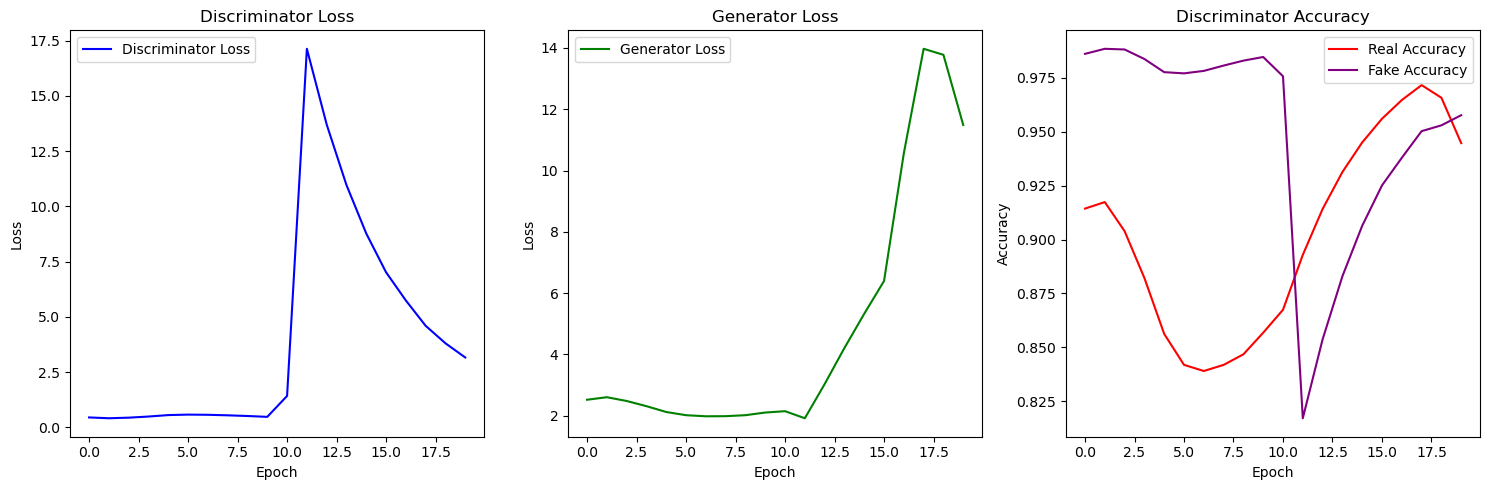

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Unique epochs for plotting
unique_epochs = sorted(list(set(epochs)))

# Smoothing the lines
def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

# Applying smoothing
smoothed_d_losses = smooth_curve(avg_d_losses)
smoothed_g_losses = smooth_curve(avg_g_losses)
smoothed_real_accuracies = smooth_curve(avg_real_accuracies)
smoothed_fake_accuracies = smooth_curve(avg_fake_accuracies)

# Plotting the graphs with enhanced visualization
plt.figure(figsize=(15, 5))

# Plot Discriminator Loss
plt.subplot(1, 3, 1)
plt.plot(unique_epochs, smoothed_d_losses, label='Discriminator Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Discriminator Loss')
plt.legend()

# Plot Generator Loss
plt.subplot(1, 3, 2)
plt.plot(unique_epochs, smoothed_g_losses, label='Generator Loss', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Generator Loss')
plt.legend()

# Plot Discriminator Accuracy
plt.subplot(1, 3, 3)
plt.plot(unique_epochs, smoothed_real_accuracies, label='Real Accuracy', color='red')
plt.plot(unique_epochs, smoothed_fake_accuracies, label='Fake Accuracy', color='purple')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Discriminator Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Applying smoothing to these data as well
smoothed_d_losses1 = smooth_curve(d_losses)
smoothed_g_losses1 = smooth_curve(g_losses)
smoothed_d_accuracies1 = smooth_curve(d_accuracies)

# Enhanced plotting
plt.figure(figsize=(12, 4))

# Plot Discriminator Loss
plt.subplot(1, 3, 1)
plt.plot(epochs, smoothed_d_losses1, label='Discriminator Loss', color='blue', marker='o')
plt.title('Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Generator Loss
plt.subplot(1, 3, 2)
plt.plot(epochs, smoothed_g_losses1, label='Generator Loss', color='green', marker='o')
plt.title('Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Discriminator Accuracy
plt.subplot(1, 3, 3)
plt.plot(epochs, smoothed_d_accuracies1, label='Discriminator Accuracy', color='red', marker='o')
plt.title('Discriminator Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Applying smoothing to these data as well
smoothed_d_losses1 = smooth_curve(d_losses)
smoothed_g_losses1 = smooth_curve(g_losses)
smoothed_d_accuracies1 = smooth_curve(d_accuracies)

# Enhanced plotting
plt.figure(figsize=(12, 4))

# Plot Discriminator Loss
plt.subplot(1, 3, 1)
plt.plot(epochs, smoothed_d_losses1, label='Discriminator Loss', color='blue')
plt.title('Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Generator Loss
plt.subplot(1, 3, 2)
plt.plot(epochs, smoothed_g_losses1, label='Generator Loss', color='green')
plt.title('Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Discriminator Accuracy
plt.subplot(1, 3, 3)
plt.plot(epochs, smoothed_d_accuracies1, label='Discriminator Accuracy', color='red')
plt.title('Discriminator Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Unique epochs for plotting
unique_epochs = sorted(list(set(epochs)))
window_size = 5

# Smoothing the lines with Simple Moving Average
def smooth_curve_SMA(points, window_size=5):
    window = np.ones(window_size) / window_size
    return np.convolve(points, window, 'valid')

# Applying SMA smoothing
smoothed_d_losses = smooth_curve_SMA(avg_d_losses)
smoothed_g_losses = smooth_curve_SMA(avg_g_losses)
smoothed_real_accuracies = smooth_curve_SMA(avg_real_accuracies)
smoothed_fake_accuracies = smooth_curve_SMA(avg_fake_accuracies)

# Adjusting 'unique_epochs' for the reduced size after convolution
adjusted_epochs = unique_epochs[:len(unique_epochs) - window_size + 1]

# Plotting the graphs with enhanced visualization
plt.figure(figsize=(15, 5))

# Plot Discriminator Loss
plt.subplot(1, 3, 1)
plt.plot(adjusted_epochs, smoothed_d_losses, label='Discriminator Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Discriminator Loss')
plt.legend()

# Plot Generator Loss
plt.subplot(1, 3, 2)
plt.plot(adjusted_epochs, smoothed_g_losses, label='Generator Loss', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Generator Loss')
plt.legend()

# Plot Discriminator Accuracy
plt.subplot(1, 3, 3)
plt.plot(adjusted_epochs, smoothed_real_accuracies, label='Real Accuracy', color='red')
plt.plot(adjusted_epochs, smoothed_fake_accuracies, label='Fake Accuracy', color='purple')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Discriminator Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Fake and real graph batch values comparision

In [ ]:
# Post-training visualization and comparison
#for epoch, batch_data in graph_data_per_epoch.items():
#    for batch_index, graph_data in enumerate(batch_data):
#        compare_graphs(graph_data, epoch, batch_index)


In [ ]:
# Heat map visualization

In [ ]:
graph_data_per_epoch[19]

[{'real_x': tensor([[ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0653],
          [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0529],
          [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0190],
          ...,
          [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0413],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0843],
          [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0307]]),
  'real_edge_index': tensor([[  0,   1,   1,  ..., 868, 880, 874],
          [  1,   0,   2,  ..., 884, 874, 880]]),
  'fake_x': tensor([[9.9793e-01, 5.9020e-08, 8.7190e-09,  ..., 3.6399e-16, 5.4974e-16,
           5.5083e-07],
          [9.9821e-01, 8.1791e-09, 1.3243e-09,  ..., 9.8999e-18, 1.7255e-17,
           2.0120e-07],
          [9.9958e-01, 1.0154e-07, 1.7725e-08,  ..., 3.7322e-16, 5.5392e-16,
           3.6398e-07],
          ...,
          [9.9910e-01, 3.9964e-04, 3.1295e-09,  ..., 2.4874e-16, 2.8865e-16,
           2.9077e-

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch import nn
import torch.nn.functional as F

#graph_data_per_epoch[19]



In [ ]:
import torch

# Assuming graph_data_per_epoch[19] contains the batches of real graph data
batches = graph_data_per_epoch[19]

# Initialize an empty tensor for all real_x and all_real_edge_indices
all_real_x = torch.empty((0, batches[0]['real_x'].size(1)))  # Adapt the size to match your feature dimensions
all_real_edge_indices = torch.empty((2, 0), dtype=torch.long)  # Shape [2, 0] for edge_index

current_max_node_index = 0  # Keep track of the current maximum node index for adjusting edge indices

for data in batches:
    # Concatenate the node features
    all_real_x = torch.cat([all_real_x, data['real_x']], dim=0)

    # Adjust the edge indices and concatenate
    adjusted_edge_index = data['real_edge_index'] + current_max_node_index
    all_real_edge_indices = torch.cat([all_real_edge_indices, adjusted_edge_index], dim=1)

    # Update the current maximum node index
    # Assuming your edge indices are 0-based, add 1 to move to the next available index
    current_max_node_index = adjusted_edge_index.max() + 1

# Now, all_real_x and all_real_edge_indices contain concatenated data from all batches


In [ ]:
for epoch, batch_data in graph_data_per_epoch.items():
    for batch_index, graph_data in enumerate(batch_data):
        graph_data = {
        "real_x": graph_data_per_epoch[19].x.clone().detach(),
        "real_edge_index": graph_data_per_epoch[19].edge_index.clone().detach(),
        "fake_x": fake_x.clone().detach(),  # Assuming fake_x is defined elsewhere
        "fake_edge_index": fake_edge_index.clone().detach()  # Assuming fake_edge_index is defined
        }

{'real_x': tensor([[ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0653],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0529],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0190],
        ...,
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0413],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0843],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0307]]), 'real_edge_index': tensor([[  0,   1,   1,  ..., 868, 880, 874],
        [  1,   0,   2,  ..., 884, 874, 880]]), 'fake_x': tensor([[9.9793e-01, 5.9020e-08, 8.7190e-09,  ..., 3.6399e-16, 5.4974e-16,
         5.5083e-07],
        [9.9821e-01, 8.1791e-09, 1.3243e-09,  ..., 9.8999e-18, 1.7255e-17,
         2.0120e-07],
        [9.9958e-01, 1.0154e-07, 1.7725e-08,  ..., 3.7322e-16, 5.5392e-16,
         3.6398e-07],
        ...,
        [9.9910e-01, 3.9964e-04, 3.1295e-09,  ..., 2.4874e-16, 2.8865e-16,
         2.9077e-08],
        [9.9019e-01, 7.2199e-0

{'real_x': tensor([[ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0148],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.2170],
        [ 0.0000,  0.0000,  1.0000,  ...,  0.0000,  0.0000, -0.2754],
        ...,
        [ 0.0000,  1.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0645],
        [ 0.0000,  0.0000,  1.0000,  ...,  0.0000,  0.0000, -0.2582],
        [ 0.0000,  0.0000,  1.0000,  ...,  0.0000,  0.0000, -0.2582]]), 'real_edge_index': tensor([[  0,   1,   1,  ..., 668, 677, 672],
        [  1,   0,   2,  ..., 681, 672, 677]]), 'fake_x': tensor([[8.7736e-01, 3.8896e-04, 2.9147e-07,  ..., 1.0202e-13, 2.0441e-13,
         2.0440e-07],
        [9.3537e-01, 2.8872e-04, 2.5406e-08,  ..., 7.3448e-16, 1.6328e-15,
         1.5896e-08],
        [9.3030e-01, 1.2406e-03, 5.8160e-07,  ..., 2.2437e-13, 4.5494e-13,
         1.0686e-07],
        ...,
        [9.9990e-01, 1.4274e-02, 1.8106e-06,  ..., 1.5216e-13, 2.4122e-13,
         2.2216e-07],
        [9.9996e-01, 2.9471e-0

{'real_x': tensor([[ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0621],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0602],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0380],
        ...,
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0197],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.1227],
        [ 0.0000,  0.0000,  1.0000,  ...,  0.0000,  0.0000, -0.4867]]), 'real_edge_index': tensor([[  0,   1,   1,  ..., 984, 991, 986],
        [  1,   0,   2,  ..., 992, 986, 991]]), 'fake_x': tensor([[9.9539e-01, 3.2591e-02, 1.6944e-07,  ..., 9.1333e-15, 1.1429e-14,
         5.1088e-07],
        [9.9725e-01, 3.8074e-02, 5.5725e-08,  ..., 1.6623e-15, 1.9906e-15,
         2.0684e-07],
        [9.9799e-01, 1.6365e-01, 3.8136e-08,  ..., 5.3390e-16, 6.6491e-16,
         5.0261e-08],
        ...,
        [9.9197e-01, 2.4284e-04, 7.2421e-07,  ..., 1.8404e-13, 2.9355e-13,
         1.4000e-07],
        [9.7633e-01, 2.9314e-0

{'real_x': tensor([[ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0613],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0094],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.1767],
        ...,
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0475],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0393],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0393]]), 'real_edge_index': tensor([[  0,   1,   1,  ..., 891, 898, 893],
        [  1,   0,   2,  ..., 900, 893, 898]]), 'fake_x': tensor([[7.6390e-01, 1.9730e-07, 1.8976e-08,  ..., 1.4249e-17, 3.4021e-17,
         1.8124e-07],
        [7.0951e-01, 3.0826e-06, 4.1125e-07,  ..., 8.0902e-15, 1.6790e-14,
         2.2423e-06],
        [6.8575e-01, 7.8432e-07, 1.5138e-07,  ..., 9.7520e-16, 1.8396e-15,
         1.3553e-06],
        ...,
        [9.2417e-01, 4.9347e-03, 1.2888e-05,  ..., 3.3468e-12, 6.5516e-12,
         1.2412e-06],
        [9.4513e-01, 8.9154e-0

{'real_x': tensor([[ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0470],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0242],
        [ 0.0000,  1.0000,  0.0000,  ...,  0.0000,  0.0000, -0.2993],
        ...,
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.1605],
        [ 0.0000,  0.0000,  1.0000,  ...,  0.0000,  0.0000, -0.4929],
        [ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0777]]), 'real_edge_index': tensor([[  0,   1,   1,  ..., 803, 816, 810],
        [  1,   0,   2,  ..., 808, 810, 816]]), 'fake_x': tensor([[9.4490e-01, 6.5695e-19, 7.4926e-18,  ..., 0.0000e+00, 0.0000e+00,
         4.2793e-13],
        [9.9999e-01, 5.4586e-16, 2.9099e-18,  ..., 0.0000e+00, 0.0000e+00,
         1.5201e-16],
        [9.4490e-01, 6.5695e-19, 7.4926e-18,  ..., 0.0000e+00, 0.0000e+00,
         4.2793e-13],
        ...,
        [9.0507e-01, 1.5275e-01, 2.1117e-03,  ..., 1.1305e-12, 1.4012e-12,
         1.1326e-06],
        [9.4576e-01, 2.1035e-0

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

# Assuming all_real_x is a tensor of shape [num_graphs, feature_dim]
# where num_graphs is the total number of real graphs concatenated,
# and feature_dim is the dimensionality of the feature vector for each graph.

# Convert tensor to numpy for compatibility with sklearn
X = all_real_x.cpu().numpy()  # Ensure it's moved to CPU and converted to NumPy

# Perform K-means clustering
num_clusters = 5  # Example, adjust based on your dataset
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(X)

# 'clusters' now contains the cluster assignments for each graph


C:\Users\Malli\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [ ]:
pip install matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Assuming 'X' is your high-dimensional data and 'clusters' contains the cluster assignments

# Perform t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X)

# Plotting the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.title('Clustering of Real Graphs using t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()
